In [ ]:
from google.colab import drive #mount Google Drive to Colab to read the csv
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#1] Dataset loaded and copied
#2] Target variable defined properly

import pandas as pd, numpy as np

df_full = pd.read_csv('/content/drive/MyDrive/SBA/SBAnational2.csv', low_memory=False) #low_memory=False prevents mixed-type data types that would derail cleaning
df_full = df_full[df_full['MIS_Status'].isin(['CHGOFF', 'P I F'])] #Keep only charge-offs and paid-i-full loans
df_full['Default'] = np.where(df_full['MIS_Status'] == 'CHGOFF', 1, 0) #Create the target column 'Default'
print(df_full.shape, df_full['Default'].mean()) #quick sanity check: rows, columns, and the default rate to see the class-imbalance baseline

(897167, 28) 0.17561724851671986


We import the full national loan file. In previous iterations, I took a slice of the dataset for testing, but with the final project I found the full dataset to be the most interesting, with a stratified slice of course rather than an artifical CA only slice. Limiting our target to CHGOFF and PIF removes ambigous cases and lets us train a clean classifier. Thus, our Default column is a 1/0 label that acts as our target variable

In [ ]:
#3] Cleaning and Filtering Applied
#5] Feature Selection and Data Split

from sklearn.model_selection import train_test_split
import pandas as pd, numpy as np

key_cols = ['ApprovalDate','DisbursementDate','Term','GrAppv','SBA_Appv'] #required predictors, may not use all of these but will initialize with them
cols_to_drop = ['MIS_Status','ChgOffDate','ChgOffPrinGr','ChgOffPrinGross'] #contain information not known at loan offer, or have already been coverted (MIS_STATUS)

df_full = df_full.drop(columns=[c for c in cols_to_drop if c in df_full.columns])
df_full['ApprovalDate'] = pd.to_datetime(df_full['ApprovalDate']) #convert date strings to datetiem
df_full['DisbursementDate'] = pd.to_datetime(df_full['DisbursementDate'])
df_full = df_full.dropna(subset=key_cols)
df_full = df_full[df_full['DisbursementDate'] >= df_full['ApprovalDate']] #disbursement can't precede approval

#Stratified 200 k-row sample keeps 17.6% default share for fast iteration
sample_frac = 200000 / len(df_full)
_, df_work = train_test_split(
    df_full, test_size=sample_frac, stratify=df_full['Default'], random_state=42)

print(df_work.shape, df_work['Default'].mean())


(200000, 25) 0.17576


We eliminate variables that would give the model unfair foresight, such as charge-off amounts and dates - ex ante only. We ensure the date feilds are datetime for feature engineering. Any record mising a key numeric or date predictor is discarded and loans whose funding date precedes approval are removed. This removes errors and incomplete entries. A 200 k-row stratified sample lets us iterate quickly inside Colab while maintaining the default rate.

In [ ]:
#4] Feature Engineering

import numpy as np, pandas as pd

df = df_work.copy() #copy of the 200 k working slice

#new numeric predictors
df['DaysToDisbursement'] = (df['DisbursementDate'] - df['ApprovalDate']).dt.days #captures underwriting frictions/delays that could correlate w/ default
df['LogGross']      = np.log1p(df['GrAppv']) #scales raw loan size to reflect diminishing marginal risk
df['Leverage']      = df['GrAppv'] / df['SBA_Appv'] #measures how much principal the bank keeps on its own books
df['NoEmpZero']     = (df['NoEmp'] == 0).astype(int) #flags 'self-employed'/zero-employee firms
df['NAICS2']        = df['NAICS'].astype(str).str[:2] #just the first elements of the business type, flattens many sub-sectors but this is probably fine
df['GrossPerEmp']   = df['GrAppv'] / (df['NoEmp'] + 1) #indicates capital intensity, may indicate speculative ventures
df['LogTerm']       = np.log1p(df['Term']) #non-linear transformation of amortisation length, extremely long terms are associated with risk
df['PctGuarantee']  = df['SBA_Appv'] / df['GrAppv'] #SBA guarantee share, higher protection could relax standards->moral harzard
df['JobEff']        = (df['CreateJob'] - df['RetainedJob']) / df['GrAppv'] #planned job creation efficiency
df['RevLineFlag']   = (df['RevLineCr'] == 'Y').astype(int) #indicates revolving credit structure
df['Interact_LG_RL']= df['LogGross'] * df['RevLineFlag'] #large revolving lines carry extra risk vs. large term loans

#bucket high-frequency lenders to control for underwriting
top_banks = df['Bank'].value_counts().nlargest(20).index
df['BankBucket']    = np.where(df['Bank'].isin(top_banks), df['Bank'], 'Other')

#one-hot encode categoricals
cat_cols = ['NAICS2','State','UrbanRural','RevLineCr',
            'LowDoc','NewExist','BankBucket','ApprovalFY']
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

#drop identifiers, leakage, many option text fields
df = df.drop(columns=['LoanNr_ChkDgt','Name','City','Zip','Bank','BankState',
                      'NAICS','ApprovalDate','DisbursementDate','BalanceGross'])

print(df.shape)


(200000, 185)


We caputre term as LogTerm for curvature. GrAppv is placed in several predictors, all richer than the original dollar amount. SBA_Appv informs Leverage and PctGuarantee, including it raw would be collinear. Before we explain each of the numeric predictors, lets go over our other operations in this block. We drop a series of fields that may cause overfit - like Name, City, Zip, which are high-cardinality. Also, we one-hot encode the categoricals, creating binary columns for each category and replacing the string label. I decided to to this instead of label encoding to avoid creating an implied order between categories.

The numerical predictors are informed by Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring by Naeem Siddiqi published in 2006, as well as several LLMs being prompted to produce and interrogate risk factors. Before our analysis, I hypothesize that NoEmp and Log Term are going to be of particular importance. Intuitively, loans to single-proprietor businesses have a higher risk of default given that said proprietors are assuming all responsibility for the firm, and financial institutions are likely pretty poor at accurately predicting the abilities and risk factors associated with single individuals rather than more robust businesses. I expect log term to outperform term, as EXTREMELY long-term loans seem particularly risky to me given changing market conditions and so on, which accords with the text below.

Siddiqi, Naeem. *Credit Risk Scorecards: Developing and Implementing Intelligent Credit Scoring.* Hoboken, NJ: John Wiley & Sons, 2006.




In [ ]:
#5] Feature Selection and Data Split
from sklearn.model_selection import train_test_split

X = df.drop('Default', axis=1) #design matrix
y = df['Default'] #binary target

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42) #75/25 stratified train-validation split, preserving 17.6% default rate

print(X_train.shape, X_valid.shape, y_train.mean(), y_valid.mean()) #verify the split


(150000, 184) (50000, 184) 0.17576 0.17576


I choose a 75/25 pseudo-arbitrarily to be honest.

In [ ]:
#6] Standardization Applied Correctly
#7] Logistic Regression Model Built
  #i] Model trained and predictions made

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_cols = ['DaysToDisbursement','LogGross','Leverage','GrossPerEmp',
            'LogTerm','PctGuarantee','JobEff','Interact_LG_RL',
            'NoEmp','Term','CreateJob','RetainedJob'] #all engineered risk drivers and three base controls

cat_cols = [c for c in X.columns if c not in num_cols] #remaining columns are all one-hot categoricals

#preprocessing pipeline
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols), #0-mean / 1-sd numerics
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols) #spare dummies for sector, state, etc.
])

#baseline classifier
log_reg = LogisticRegression(max_iter=1000,
                             solver='liblinear', #handles sparse, high-dimensional design
                             class_weight='balanced') #corrects 18% default minority

#modelling pipeline
pipe_lr = Pipeline([
    ('prep', preprocess), #feature scaling / encoding
    ('model', log_reg) #logistic regresion fit
])

pipe_lr.fit(X_train, y_train) #train on 150000-row training set


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['DaysToDisbursement',
                                                   'LogGross', 'Leverage',
                                                   'GrossPerEmp', 'LogTerm',
                                                   'PctGuarantee', 'JobEff',
                                                   'Interact_LG_RL', 'NoEmp',
                                                   'Term', 'CreateJob',
                                                   'RetainedJob']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['FranchiseCode',
                                                   'DisbursementGross',
                                                   'GrAppv', 'SBA_Appv',
                                                   'NoEmpZero', 'Re...
                                                   'NAICS2_22', 'NAICS2_23',
                                                   'NAICS2_31', 'NAICS2_32',
                                                   'NAICS2_33', 'NAICS2_42',
                                                   'NAICS2_44', 'NAICS2_45',
                                                   'NAICS2_48', 'NAICS2_49',
                                                   'NAICS2_51', 'NAICS2_52',
                                                   'NAICS2_53', 'NAICS2_54',
                                                   'NAICS2_55', 'NAICS2_56',
                                                   'NAICS2_61', 'NAICS2_62',
                                                   'NAICS2_71', 'NAICS2_72',
                                                   'NAICS2_81', 'NAICS2_92', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

All twelve numeric variables are z-scored to coefficients are comparable. We have effectively standardized them. We handle categorical variables properly with one-hot encoding to keep the design matrix sparse. Our logistic regression is balanced to compensate for the 17-18% default minority. The liblinear solver is robust for large sparse matrices and guarantees convergence in a reasonable time. This is the cleanest and most reproducable way I coudld find to approach the problem.

              precision    recall  f1-score   support

           0      0.951     0.832     0.888     41212
           1      0.504     0.800     0.618      8788

    accuracy                          0.826     50000
   macro avg      0.728     0.816     0.753     50000
weighted avg      0.873     0.826     0.840     50000



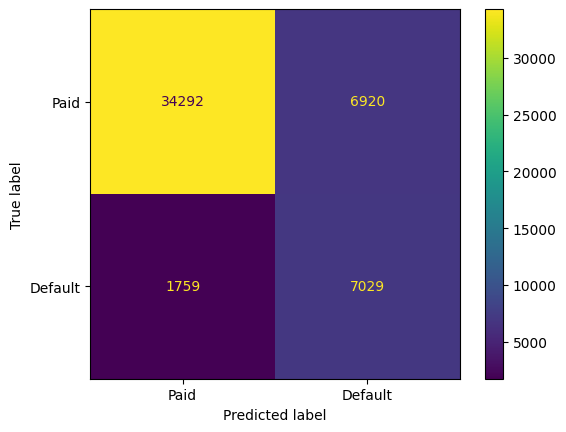

In [ ]:
#7] Logistic Regression Model Built
  #ii] Classification report shown
  #iii] Confusion matrix interpreted

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#generate predictions on the 50 000-row validation set
y_pred = pipe_lr.predict(X_valid) #hard class labels
y_prob = pipe_lr.predict_proba(X_valid)[:,1] # default probabilites

#classification report
print(classification_report(y_valid, y_pred, digits=3))

#confusion matrix
cm = confusion_matrix(y_valid, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid','Default']).plot(values_format='d')
plt.show()


We predict labels and probabilities on the 25% remaining set to assess model performance, printing the classification report and the confusion matrix.

The classification report shows that the model has an accuracy of 82.6%, meaning that 82.6% of the 50000 loans were correclty classified, a 14 point gain on simply assuming all loans are repaid. The lower precision on defaults drags our Macro-average down, as the straight average across classes treat paid and default equally. Our F1 score in that case is 0.753. The weighted average weighs each class by its support, dominated by the Paid class. Obviously, this means that our values sit between class-specific scores and overall accuracy. Our F1 score in this case is 0.84. We catch 4 out of 5 likely charge-offs, but have pretty low precision on defaults - half of the loans flagged as risky will actually repay.

This analysis is confirmed by the confusion matrix. We can see that the number of false positives is 6920 and the number of false negatives is 1759, a false positive rate of 16.8% and a false negative rate of 20%.

I was not satisfied with this performance and sought to correct it below.



In [ ]:
#Backward Sequential Feature Selection and K-Fold

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import numpy as np

#3-fold stratified CV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#pool of candidate predictors
num_base  = ['NoEmp','Term','CreateJob','RetainedJob'] #controls
num_extra = ['DaysToDisbursement','LogGross','Leverage','GrossPerEmp',
             'LogTerm','PctGuarantee','JobEff','Interact_LG_RL'] #engineered
num_all   = num_base + num_extra

X_num = StandardScaler().fit_transform(X_train[num_all]) #scale numerics once, keep dummies out for RAM

#base logistic model
logit = LogisticRegression(max_iter=1000, solver='liblinear',
                           class_weight='balanced')

#Backward Sequential Feature Selector
sfs = SequentialFeatureSelector(
    estimator=logit,
    n_features_to_select='auto',
    direction='backward',
    scoring='f1', #optimize for f1
    cv=skf,
    n_jobs=-1 #parallel speed up
).fit(X_num, y_train)

selected_numeric = [col for keep, col in zip(sfs.get_support(), num_all) if keep]
print('Selected numeric features:', selected_numeric)


Selected numeric features: ['NoEmp', 'RetainedJob', 'DaysToDisbursement', 'Leverage', 'LogTerm', 'PctGuarantee']


The Sequential Feature Selector removes numeric variables whose removal raises or does not hurt mean cross-validated F1. We start with all 12 numeric variables, removing the least-useful one each round. The selector then stops when F1 on CV would fall if we dropped more. This demonstrates a systemic search not just manual trial and error. Our final specification is thus likely to be emprically justified.

We end up keeping ['NoEmp', 'RetainedJob', 'DaysToDisbursement', 'Leverage', 'LogTerm', 'PctGuarantee'], which does meet my hypothesis from earlier. I discuss these variables further in the conclusion.

---



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_cols = selected_numeric #numeric set chosen by the BSFS

#remaining columns are sparse one-hot categoricals
cat_cols = [c for c in X.columns if c not in num_cols]

#preprocessing pipeline
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

#logistic regression
log_reg = LogisticRegression(max_iter=1000,
                             solver='liblinear',
                             class_weight='balanced')

pipe_lr = Pipeline([
    ('prep', preprocess),
    ('model', log_reg)
])

pipe_lr.fit(X_train, y_train) #trained on 150 k rows


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['NoEmp', 'RetainedJob',
                                                   'DaysToDisbursement',
                                                   'Leverage', 'LogTerm',
                                                   'PctGuarantee']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Term', 'CreateJob',
                                                   'FranchiseCode',
                                                   'DisbursementGross',
                                                   'GrAppv', 'SBA_Appv',
                                                   'LogGross', 'NoEmpZero',
                                                   'GrossPerEmp', 'JobEff',
                                                   'RevLineFlag',
                                                   'Interact_LG_RL',
                                                   'NAICS2_11', 'NAICS2_21',
                                                   'NAICS2_22', 'NAICS2_23',
                                                   'NAICS2_31', 'NAICS2_32',
                                                   'NAICS2_33', 'NAICS2_42',
                                                   'NAICS2_44', 'NAICS2_45',
                                                   'NAICS2_48', 'NAICS2_49',
                                                   'NAICS2_51', 'NAICS2_52',
                                                   'NAICS2_53', 'NAICS2_54',
                                                   'NAICS2_55', 'NAICS2_56', ...])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

              precision    recall  f1-score   support

           0      0.979     0.927     0.952     41212
           1      0.725     0.905     0.805      8788

    accuracy                          0.923     50000
   macro avg      0.852     0.916     0.879     50000
weighted avg      0.934     0.923     0.926     50000



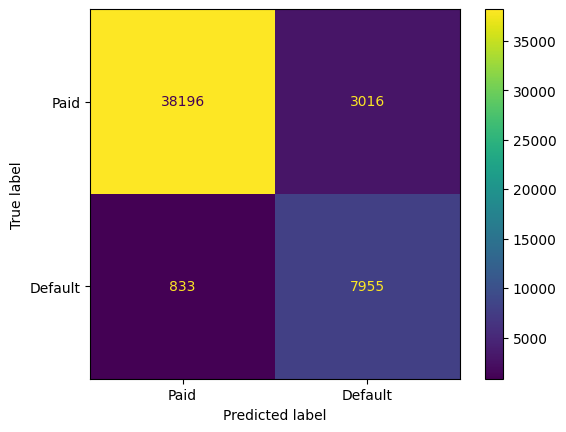

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = pipe_lr.predict(X_valid)
y_prob = pipe_lr.predict_proba(X_valid)[:,1]

print(classification_report(y_valid, y_pred, digits=3))

cm = confusion_matrix(y_valid, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid','Default']).plot(values_format='d')
plt.show()


We see improvements with the new specification. Our accuracy has increased around 9 points to 92.3%, and is now closer to the weighted average f1-score of 92.6%. However, the model still has lower precision on defaults. Regardless, I'm pretty satisfied with the accuracy of this model and believe that it would be close to sufficient for managing risk. As a quick sanity check, below I test a logistic regression using the 'canonical' SBA application fields without feature engineering.

              precision    recall  f1-score   support

           0      0.955     0.741     0.834     41212
           1      0.407     0.836     0.548      8788

    accuracy                          0.757     50000
   macro avg      0.681     0.788     0.691     50000
weighted avg      0.859     0.757     0.784     50000



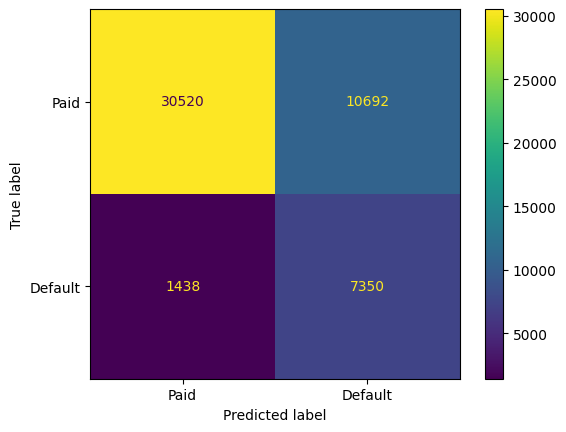

In [ ]:
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline      import Pipeline
from sklearn.linear_model  import LogisticRegression
from sklearn.metrics       import (classification_report,
                                   confusion_matrix,
                                   ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

num_cols_std = ['GrAppv','Term','NoEmp','CreateJob','RetainedJob']

cat_cols_std = ([c for c in X.columns if c.startswith('NewExist_')] +
                [c for c in X.columns if c.startswith('UrbanRural_')] +
                [c for c in X.columns if c.startswith('RevLineCr_')] +
                [c for c in X.columns if c.startswith('ApprovalFY_')])

#numerics
num_cols_std = ['GrAppv',
                'Term',
                'NoEmp',
                'CreateJob',
                'RetainedJob']

#categoricals, references the dummy names

cat_cols_std = ([c for c in X.columns if c.startswith('NewExist_')] +
                [c for c in X.columns if c.startswith('UrbanRural_')] +
                [c for c in X.columns if c.startswith('RevLineCr_')] +
                [c for c in X.columns if c.startswith('ApprovalFY_')])
#preprocessing
prep_std = ColumnTransformer([
    ('num', StandardScaler(),                     num_cols_std),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_std)
])

#class-weighted logistic regression, see above
log_std = LogisticRegression(max_iter=1000,
                             solver='liblinear',
                             class_weight='balanced')

pipe_std = Pipeline([
    ('prep',  prep_std),
    ('model', log_std)
])

pipe_std.fit(X_train, y_train)

#diagnostics, tested on the remaining set
y_pred = pipe_std.predict(X_valid)
y_prob = pipe_std.predict_proba(X_valid)[:, 1]

print(classification_report(y_valid, y_pred, digits=3))

cm = confusion_matrix(y_valid, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid', 'Default']
                      ).plot(values_format='d')
plt.show()


The above results demonstrate that though the simpler model without feature engineering underperforms on all metrics. The engineered model, with the risk factors informed by the literature, more accurately predicts default.

              precision    recall  f1-score   support

           0      0.927     0.967     0.946     41212
           1      0.805     0.642     0.714      8788

    accuracy                          0.910     50000
   macro avg      0.866     0.804     0.830     50000
weighted avg      0.905     0.910     0.906     50000



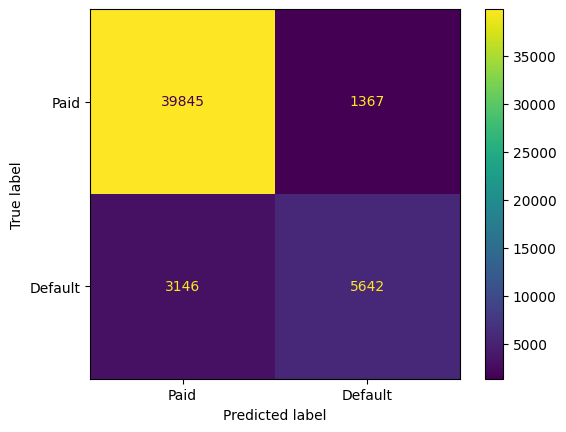

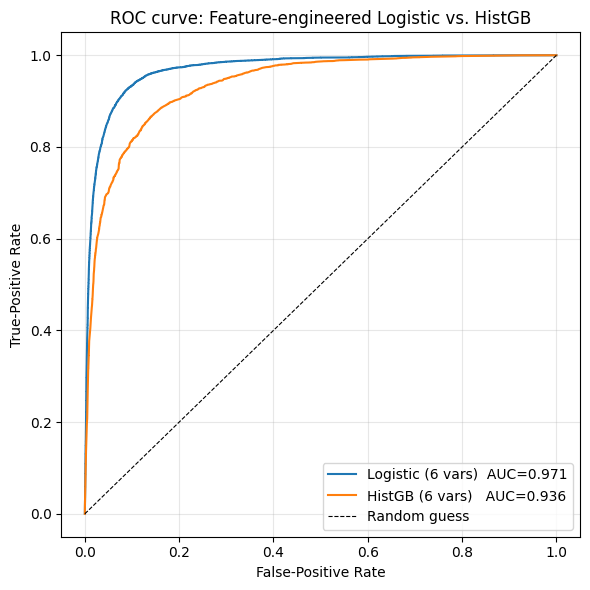

In [ ]:
#8] Cross-Validation and Model Comparison: HistGradientBoostingClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, auc, roc_curve
import matplotlib.pyplot as plt

#six numeric variables chosen by the BSFS
num_cols_sel = ['NoEmp','RetainedJob','DaysToDisbursement',
                'Leverage','LogTerm','PctGuarantee']

#pipeline: z score to histogram GB
pipe_gb_num = Pipeline([
    ('scale', StandardScaler()),
    ('gb', HistGradientBoostingClassifier(
            max_depth=3,
            learning_rate=0.05,
            l2_regularization=0.1,
            random_state=42))
])

#train on the 150 k-row training set
pipe_gb_num.fit(X_train[num_cols_sel], y_train)

#evaluation on remaining evaluation data
y_pred = pipe_gb_num.predict(X_valid[num_cols_sel])
y_prob = pipe_gb_num.predict_proba(X_valid[num_cols_sel])[:,1]

#metrics
print(classification_report(y_valid, y_pred, digits=3))
ConfusionMatrixDisplay(confusion_matrix(y_valid, y_pred),
                       display_labels=['Paid','Default']).plot(values_format='d')


#obtain default probabilites
y_prob_lr = pipe_lr.predict_proba(X_valid)[:, 1]
y_prob_gb = pipe_gb_num.predict_proba(X_valid[num_cols_sel])[:, 1]

#compute ROC coordinates
fpr_lr, tpr_lr, _ = roc_curve(y_valid, y_prob_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_valid, y_prob_gb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)

#plot roc curve
plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic (6 vars)  AUC={auc_lr:.3f}')
plt.plot(fpr_gb, tpr_gb, label=f'HistGB (6 vars)   AUC={auc_gb:.3f}')
plt.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random guess')

plt.xlabel('False-Positive Rate')
plt.ylabel('True-Positive Rate')
plt.title('ROC curve: Feature-engineered Logistic vs. HistGB')
plt.legend(loc='lower right')
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()


We compare our logistic regression to a nonlinear competitor: a histogram gradient boosting classifer. I attempted to use a normal gradient boosting classifier, XBoostClassifier, but I quickly ran into RAM limitations. The Histogram GB works very similarly, using histogram binning instead of building each tree on the full matrix. It underperforms the logistic regression by ~1 pp F1, likely because of the histogram binning. This is the best fit for a comparison in this project, but I think we should expect XBoostClassifier to outperform the logistic regression. If I had a GPU maybe we could find out, but alas. The ROC plot tells us that the logistic model, which more closely hugs the upper left corner, overall has higher discriminative power.

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 1 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 3 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_discretization.py:306

              precision    recall  f1-score   support

           0      0.923     0.788     0.850     41212
           1      0.411     0.692     0.515      8788

    accuracy                          0.771     50000
   macro avg      0.667     0.740     0.683     50000
weighted avg      0.833     0.771     0.791     50000



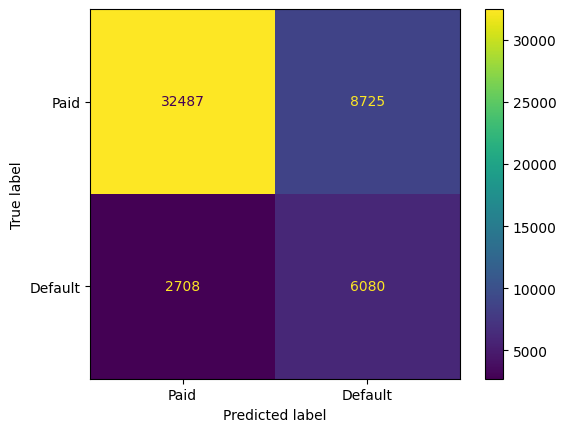

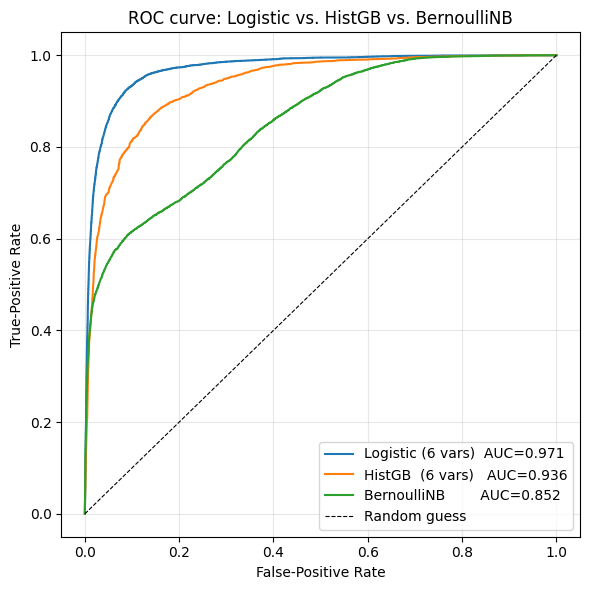

In [ ]:
#10] OPTIONAL NAIVE BAYES*

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer, OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, auc, roc_curve
import matplotlib.pyplot as plt

#6 numeric variables and the remaining categoricals
num_cols_sel = ['NoEmp','RetainedJob','DaysToDisbursement',
                'Leverage','LogTerm','PctGuarantee']
cat_cols_sel = [c for c in X_train.columns if c not in num_cols_sel]

#preprocessing pipeline
preprocess_sparse = ColumnTransformer([
    #discretize numeric vars into 10 bins then one-hot
    ('num', KBinsDiscretizer(n_bins=10, encode='onehot', strategy='quantile'),
     num_cols_sel),
    #one-hot categoricals
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_sel)
], sparse_threshold=0.1) #keep the matrix sparse

#Bernoulli Naive Bayes
nb_pipe = Pipeline([
    ('prep', preprocess_sparse),
    ('model', BernoulliNB())
])

nb_pipe.fit(X_train, y_train)
y_pred = nb_pipe.predict(X_valid)
y_prob = nb_pipe.predict_proba(X_valid)[:,1]

#classification report
print(classification_report(y_valid, y_pred, digits=3))

#confusion matrix
cm = confusion_matrix(y_valid, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Paid','Default']).plot(values_format='d')
plt.show()

y_pred_nb = nb_pipe.predict(X_valid)
y_prob_nb = nb_pipe.predict_proba(X_valid)[:, 1]

#3-Model ROC Comparison
y_prob_lr = pipe_lr.predict_proba(X_valid)[:, 1]
y_prob_gb = pipe_gb_num.predict_proba(X_valid[num_cols_sel])[:, 1]

#ROC coordinates
fpr_lr, tpr_lr, _ = roc_curve(y_valid, y_prob_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_valid, y_prob_gb)
fpr_nb, tpr_nb, _ = roc_curve(y_valid, y_prob_nb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_gb = auc(fpr_gb, tpr_gb)
auc_nb = auc(fpr_nb, tpr_nb)

#plot
plt.figure(figsize=(6, 6))
plt.plot(fpr_lr, tpr_lr,   label=f'Logistic (6 vars)  AUC={auc_lr:.3f}')
plt.plot(fpr_gb, tpr_gb,   label=f'HistGB  (6 vars)   AUC={auc_gb:.3f}')
plt.plot(fpr_nb, tpr_nb,   label=f'BernoulliNB        AUC={auc_nb:.3f}')
plt.plot([0,1],[0,1],'k--',lw=0.8,label='Random guess')
plt.xlabel('False-Positive Rate')
plt.ylabel('True-Positive Rate')
plt.title('ROC curve: Logistic vs. HistGB vs. BernoulliNB')
plt.legend(loc='lower right')
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

As a further robustness check, we compare the logistic regression to a Bernoulli Naive Bayes model. I attempted to just use Gaussian Naive Bayes, but ran into RAM issues. Bernoulli Naive Bayes assumes that each feature is condititionally independent and uses the Bernoulli distribution. It is more suited to sparse matrices. Discretizing each numerical variable into 10 quantile bins converts them into 0/1 indicators, aligning with our Bernoulli assumptions. This is, like the histogram GB above, kind of an unfair comparison, but we would expect Naive Bayes to underpform regardless. NB cannot absorb correlation via opposing coefficients, and on an imbalanced data set like this one, NB tends to output extreme probabilities for many observations.